In [ ]:
!pip install -q transformers datasets accelerate

import pandas as pd
import numpy as np
import os
import pickle
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, auc,
                             classification_report)
from transformers import (RobertaTokenizer, RobertaForSequenceClassification,
                          get_linear_schedule_with_warmup)
from torch.optim import AdamW
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE = '/content/drive/My Drive/SarcasmProject'
df = pd.read_csv(f'{DRIVE}/data/train-balanced-sarcasm.csv')
df.dropna(subset=['comment', 'parent_comment'], inplace=True)
df.reset_index(drop=True, inplace=True)

# RoBERTa is expensive — use 100k samples
SUBSET = 100000
df_sub = df.sample(n=SUBSET, random_state=42).reset_index(drop=True)

train_df, test_df = train_test_split(
    df_sub, test_size=0.2, random_state=42, stratify=df_sub['label']
)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Train: {len(train_df)}, Test: {len(test_df)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train: 80000, Test: 20000


In [ ]:
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

MAX_LEN = 96  # Increased to handle 2 messages

def tokenize_batch(df_split):
    # Format: A: parent [SEP] B: comment
    texts = "A: " + df_split['parent_comment'].astype(str) + " [SEP] B: " + df_split['comment'].astype(str)
    return tokenizer(
        texts.tolist(),
        padding='max_length',
        truncation=True,
        max_length=MAX_LEN,
        return_tensors='pt'
    )

print("Tokenizing train set...")
train_enc = tokenize_batch(train_df)
print("Tokenizing test set...")
test_enc = tokenize_batch(test_df)

# Show BPE tokenization example
example_parent = train_df['parent_comment'].iloc[0]
example_comment = train_df['comment'].iloc[0]
example_combined = f"A: {example_parent} [SEP] B: {example_comment}"
tokens = tokenizer.tokenize(example_combined[:150])
print(f"\nExample: {example_combined[:150]}")
print(f"BPE tokens: {tokens[:20]}")

# Create DataLoaders
BATCH_SIZE = 32

train_dataset = TensorDataset(
    train_enc['input_ids'],
    train_enc['attention_mask'],
    torch.tensor(train_df['label'].values, dtype=torch.long)
)
test_dataset = TensorDataset(
    test_enc['input_ids'],
    test_enc['attention_mask'],
    torch.tensor(test_df['label'].values, dtype=torch.long)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing train set...
Tokenizing test set...

Example: A: Literally, do not ever look at cbc commentators. It's like they have a IQ filter where you must have below 80 IQ to comment. Whatever the opposite 
BPE tokens: ['A', ':', 'ĠLiterally', ',', 'Ġdo', 'Ġnot', 'Ġever', 'Ġlook', 'Ġat', 'Ġc', 'bc', 'Ġcommentators', '.', 'ĠIt', "'s", 'Ġlike', 'Ġthey', 'Ġhave', 'Ġa', 'ĠIQ']
Train batches: 2500, Test batches: 625


In [ ]:
model = RobertaForSequenceClassification.from_pretrained(
    'roberta-base',
    num_labels=2
)
model.to(device)

# All parameters are trainable (full fine-tune)
total = sum(p.numel() for p in model.parameters())
print(f"Parameters: {total:,} (all trainable)")

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Parameters: 124,647,170 (all trainable)


In [ ]:
EPOCHS = 5
LR = 2e-5

optimizer = AdamW(model.parameters(), lr=LR, eps=1e-8, weight_decay=0.01)

total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

best_val_acc = 0
patience_counter = 0
PATIENCE = 2

for epoch in range(EPOCHS):
    # --- Training ---
    model.train()
    epoch_loss = 0
    for batch_idx, batch in enumerate(train_loader):
        input_ids, attention_mask, labels = [b.to(device) for b in batch]

        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        epoch_loss += loss.item()

        if (batch_idx + 1) % 200 == 0:
            print(f"  Epoch {epoch+1}, Batch {batch_idx+1}/{len(train_loader)}, Loss: {loss.item():.4f}")

    avg_loss = epoch_loss / len(train_loader)

    # --- Validation ---
    model.eval()
    correct, total_val = 0, 0
    with torch.no_grad():
        for batch in test_loader:
            input_ids, attention_mask, labels = [b.to(device) for b in batch]
            outputs = model(input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1)
            correct += (preds == labels).sum().item()
            total_val += labels.size(0)

    val_acc = correct / total_val
    print(f"Epoch {epoch+1}/{EPOCHS} — Loss: {avg_loss:.4f}, Val Acc: {val_acc:.4f}")

    # Early stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        # Save best model weights
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

# Load best weights
model.load_state_dict(best_state)
print(f"\n✓ Training complete (best val acc: {best_val_acc:.4f})")

  Epoch 1, Batch 200/2500, Loss: 0.6809
  Epoch 1, Batch 400/2500, Loss: 0.7605
  Epoch 1, Batch 600/2500, Loss: 0.5665
  Epoch 1, Batch 800/2500, Loss: 0.6165
  Epoch 1, Batch 1000/2500, Loss: 0.5668
  Epoch 1, Batch 1200/2500, Loss: 0.5742
  Epoch 1, Batch 1400/2500, Loss: 0.6166
  Epoch 1, Batch 1600/2500, Loss: 0.5797
  Epoch 1, Batch 1800/2500, Loss: 0.6741
  Epoch 1, Batch 2000/2500, Loss: 0.6333
  Epoch 1, Batch 2200/2500, Loss: 0.6406
  Epoch 1, Batch 2400/2500, Loss: 0.4561
Epoch 1/5 — Loss: 0.5831, Val Acc: 0.7301
  Epoch 2, Batch 200/2500, Loss: 0.4681
  Epoch 2, Batch 400/2500, Loss: 0.5458
  Epoch 2, Batch 600/2500, Loss: 0.5212
  Epoch 2, Batch 800/2500, Loss: 0.6768
  Epoch 2, Batch 1000/2500, Loss: 0.6380
  Epoch 2, Batch 1200/2500, Loss: 0.5222
  Epoch 2, Batch 1400/2500, Loss: 0.7415
  Epoch 2, Batch 1600/2500, Loss: 0.5011
  Epoch 2, Batch 1800/2500, Loss: 0.3070
  Epoch 2, Batch 2000/2500, Loss: 0.4295
  Epoch 2, Batch 2200/2500, Loss: 0.3961
  Epoch 2, Batch 2400/2

In [ ]:
model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids, attention_mask, labels = [b.to(device) for b in batch]
        outputs = model(input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=1)[:, 1]
        preds = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

y_test = np.array(all_labels)
y_pred = np.array(all_preds)
y_prob = np.array(all_probs)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=" * 40)
print("    RoBERTa TRANSFORMER — RESULTS")
print("=" * 40)
print(f"  Accuracy:  {acc:.4f} ({acc*100:.1f}%)")
print(f"  Precision: {prec:.4f}")
print(f"  Recall:    {rec:.4f}")
print(f"  F1 Score:  {f1:.4f}")
print("=" * 40)
print(classification_report(y_test, y_pred, target_names=['Genuine', 'Sarcastic']))


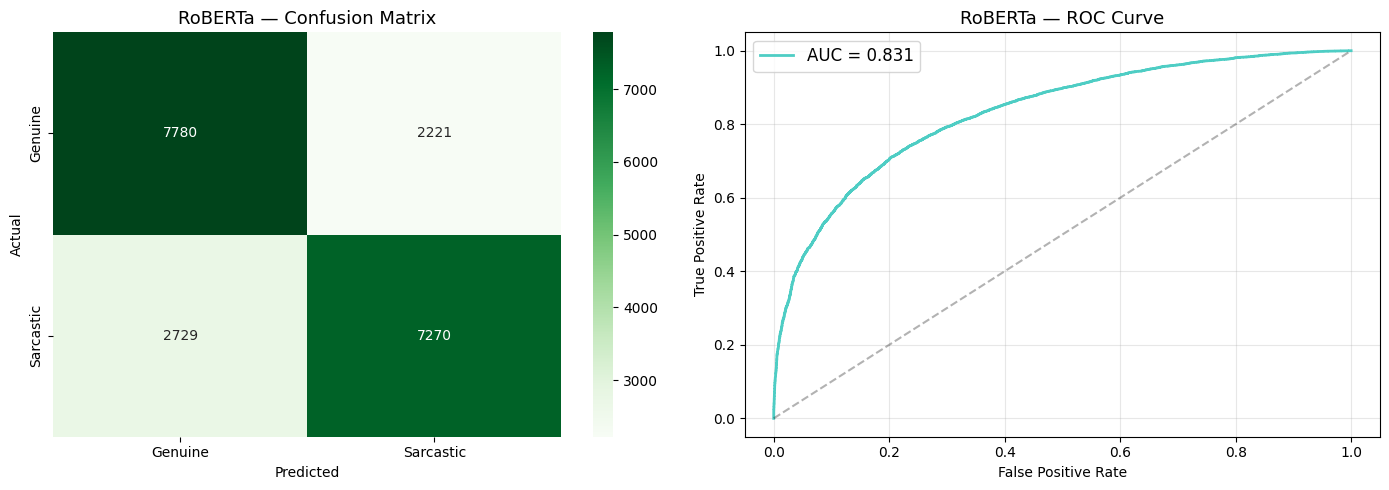

✓ Saved: bert_results.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['Genuine', 'Sarcastic'],
            yticklabels=['Genuine', 'Sarcastic'])
axes[0].set_title('RoBERTa — Confusion Matrix', fontsize=13)
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='#4ECDC4', linewidth=2, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[1].set_title('RoBERTa — ROC Curve', fontsize=13)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=12)
axes[1].grid(alpha=0.3)

plt.tight_layout()
os.makedirs(f'{DRIVE}/outputs', exist_ok=True)
plt.savefig(f'{DRIVE}/outputs/bert_results.png', dpi=150)
plt.show()
print("✓ Saved: bert_results.png")

In [ ]:
# Save RoBERTa model and tokenizer
save_path = f'{DRIVE}/models/roberta_model'
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)
print(f"✓ RoBERTa model saved to {save_path}")

# Save metrics for Phase 5 comparison
metrics = {'model': 'RoBERTa', 'accuracy': acc, 'precision': prec,
           'recall': rec, 'f1': f1, 'auc': roc_auc}
with open(f'{DRIVE}/models/roberta_metrics.pkl', 'wb') as f:
    pickle.dump(metrics, f)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✓ RoBERTa model saved to /content/drive/My Drive/SarcasmProject/models/roberta_model
